# Detection Metrics Dashboard

This notebook loads the JSON summaries produced by the benchmark (`experiments/compute_metrics.py`) and creates publication-ready plots:

- COCO-style AP (IoU 0.50:0.95) and AP@0.5 for both traditional and VLM models.
- Latency statistics (mean, median, p95) visualized side-by-side.
- Optional long-tail breakdown for LVIS unseen categories.

## Usage
1. Ensure you have run the evaluation script:
   ```bash
   python experiments/compute_metrics.py --dataset all > results/metrics_summary.json
   ```
   Alternatively, adapt the `SUMMARY_FILE` path in the next cell to point to your summary JSON.
2. Execute this notebook to generate plots for the paper.

The notebook assumes you are running inside the project root directory.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

PROJECT_ROOT = Path.cwd()
SUMMARY_FILE = Path('../results') / "metrics_summary.json"

DATASET_LABELS = {
    "lvis-unseen": "LVIS (Unseen)",
    "coco-unseen": "COCO (Unseen)",
    "coco2017-val": "COCO 2017 Val",
}

def dataset_label(key: str) -> str:
    return DATASET_LABELS.get(key, key.replace('-', ' ').upper())

if not SUMMARY_FILE.exists() or SUMMARY_FILE.stat().st_size == 0:
    raise FileNotFoundError("Summary file not found or empty. Run \"python experiments/compute_metrics.py --dataset all > results/metrics_summary.json\" first.")


In [2]:
def save_figure(fig, name: str, output_dir: Path = PROJECT_ROOT / "results" / "figures"):
    output_dir.mkdir(parents=True, exist_ok=True)
    for ext in ("png", "pdf"):
        fig_path = output_dir / f"{name}.{ext}"
        fig.savefig(fig_path, bbox_inches="tight")
        print(f"Saved: {fig_path}")

def load_summary(summary_path: Path) -> pd.DataFrame:
    """Load the JSON summary into a tidy DataFrame."""
    try:
        with summary_path.open('r', encoding='utf-8') as fh:
            data = json.load(fh)
    except json.JSONDecodeError as exc:
        raise ValueError('Failed to parse metrics summary JSON. Ensure the file contains valid JSON.') from exc

    records = []
    for dataset, entries in data.items():
        for model_info in entries:
            record = {
                'dataset': dataset,
                'model': model_info['model'],
                'family': model_info.get('family', 'unknown'),
                'AP': model_info.get('ap'),
                'AP50': model_info.get('ap50'),
                'latency_mean': model_info.get('latency_mean'),
                'latency_median': model_info.get('latency_median'),
                'latency_p95': model_info.get('latency_p95'),
                'label_accuracy': model_info.get('label_accuracy'),
            }
            records.append(record)
    df = pd.DataFrame(records)
    df = df.sort_values(['dataset', 'family', 'model']).reset_index(drop=True)
    return df


metrics_df = load_summary(SUMMARY_FILE)
metrics_df.head()


,dataset,model,family,AP,AP50,latency_mean,latency_median,latency_p95,label_accuracy
0,coco2017-val,grounding_dino,traditional,0.073079,0.095342,0.110914,0.111802,0.121823,0.269769
1,coco2017-val,owl_vit,traditional,0.027787,0.043251,0.024105,0.024063,0.025706,0.221271
2,coco2017-val,yolo_world,traditional,0.057252,0.075801,0.016150,0.015471,0.017178,0.221193
3,coco2017-val,Qwen3-VL-8B-Instruct,vlm,0.000013,0.000048,12.478333,5.845668,10.893134,0.206719
4,coco2017-val,gemini-2.5-flash,vlm,0.000037,0.000127,3.362666,2.128692,4.468948,0.313987


In [3]:
def plot_bar_metric(df: pd.DataFrame, metric: str, title: str, ylabel: str, figsize=(10, 6)):
    """Render a horizontal bar chart comparing models on a given metric."""
    if metric not in df.columns:
        return None, None
    subset = df.dropna(subset=[metric])
    if subset.empty:
        return None, None
    fig, ax = plt.subplots(figsize=figsize)
    order = subset.sort_values(metric, ascending=False)
    palette = sns.color_palette('Set2', n_colors=subset['family'].nunique())
    sns.barplot(
        data=order,
        y='model',
        x=metric,
        hue='family',
        dodge=False,
        palette=palette,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel(ylabel)
    ax.set_ylabel('Model')
    ax.legend(title='Family', loc='lower right')
    ax.set_xlim(left=0)
    sns.despine(ax=ax)

    save_figure(fig, name=title.replace(' ', '_'))
    
    return fig, ax


def plot_latency_box(df: pd.DataFrame, title: str, figsize=(10, 6)):
    """Generate a bar plot of latency statistics (mean/median/p95)."""
    melted = df.melt(
        id_vars=['dataset', 'model', 'family'],
        value_vars=['latency_mean', 'latency_median', 'latency_p95'],
        var_name='latency_stat',
        value_name='seconds',
    )
    melted = melted.dropna(subset=['seconds'])
    if melted.empty:
        return None, None
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(
        data=melted,
        x='seconds',
        y='model',
        hue='latency_stat',
        palette='Blues',
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel('Latency (s)')
    ax.set_ylabel('Model')
    ax.legend(title='Statistic', loc='upper right')
    ax.set_xlim(left=0)
    sns.despine(ax=ax)

    save_figure(fig, name=title.replace(' ', '_'))
    return fig, ax


,dataset,model,family,AP,AP50,latency_mean,latency_median,latency_p95,label_accuracy
0,coco2017-val,grounding_dino,traditional,0.073079,0.095342,0.110914,0.111802,0.121823,0.269769
1,coco2017-val,owl_vit,traditional,0.027787,0.043251,0.024105,0.024063,0.025706,0.221271
2,coco2017-val,yolo_world,traditional,0.057252,0.075801,0.016150,0.015471,0.017178,0.221193
3,coco2017-val,Qwen3-VL-8B-Instruct,vlm,0.000013,0.000048,12.478333,5.845668,10.893134,0.206719
4,coco2017-val,gemini-2.5-flash,vlm,0.000037,0.000127,3.362666,2.128692,4.468948,0.313987
5,coco2017-val,gemma-3-12b-it,vlm,0.000000,0.000000,15.415180,14.739154,18.191313,0.000000
6,coco2017-val,gpt-5,vlm,0.002410,0.007619,9.269682,6.076331,29.565728,0.292502
7,coco2017-val,llava-v1.6-mistral-7b-hf,vlm,0.000000,0.000000,69.255604,1.565973,251.231600,0.353635


Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/COCO_2017_Val_–_AP_(IoU_0.50:0.95).png
Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/COCO_2017_Val_–_AP_(IoU_0.50:0.95).pdf


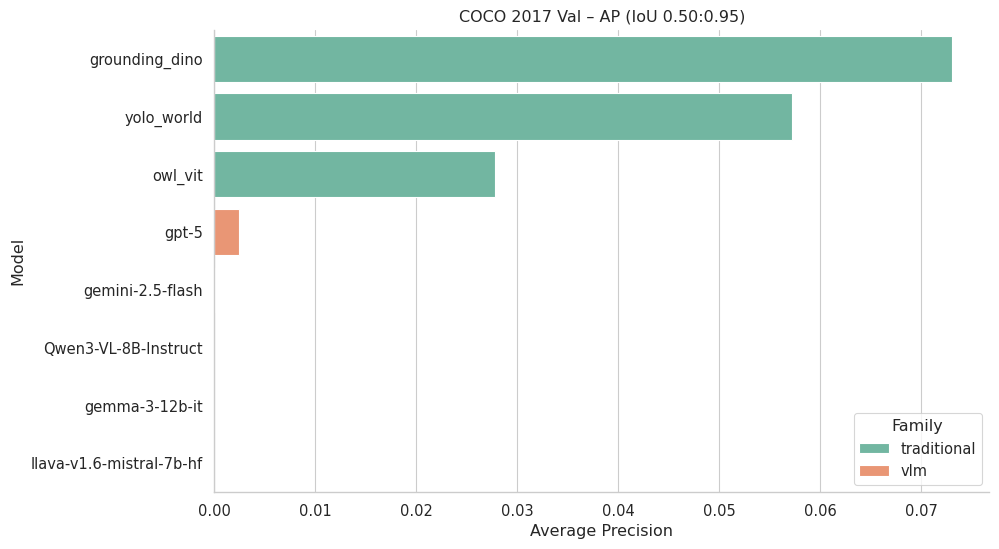

Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/COCO_2017_Val_–_AP@0.5.png
Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/COCO_2017_Val_–_AP@0.5.pdf


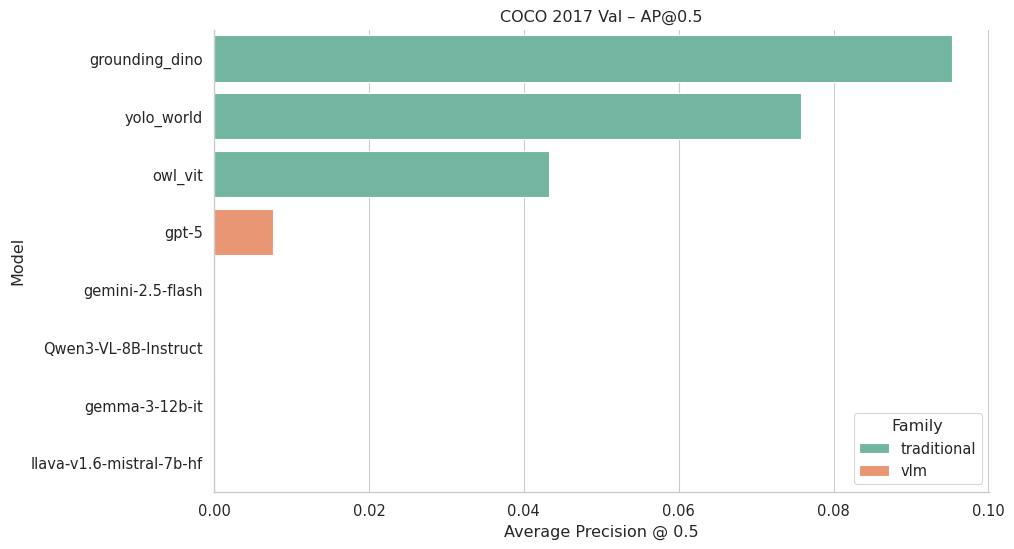

Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/COCO_2017_Val_–_Label_Accuracy.png
Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/COCO_2017_Val_–_Label_Accuracy.pdf


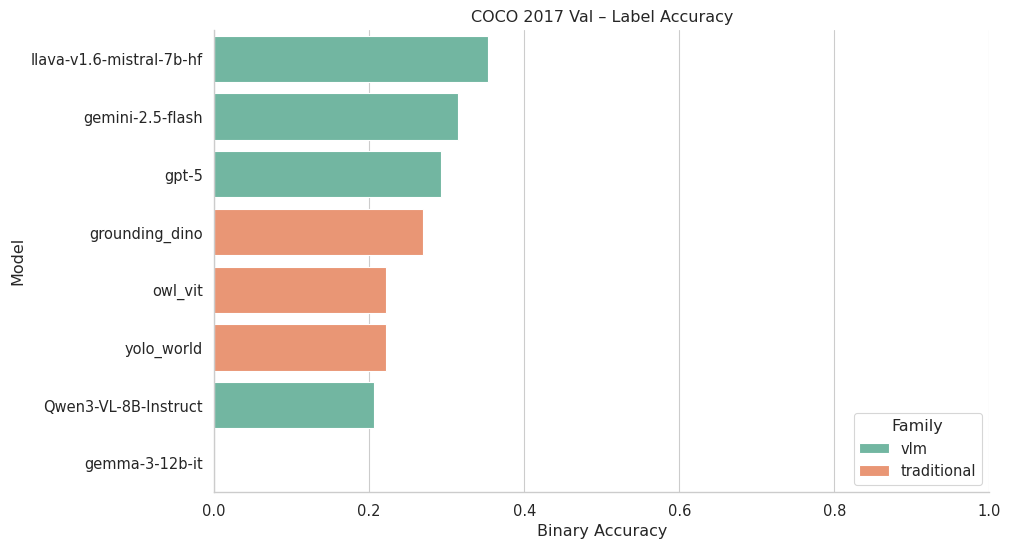

Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/COCO_2017_Val_–_Latency_Statistics.png
Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/COCO_2017_Val_–_Latency_Statistics.pdf


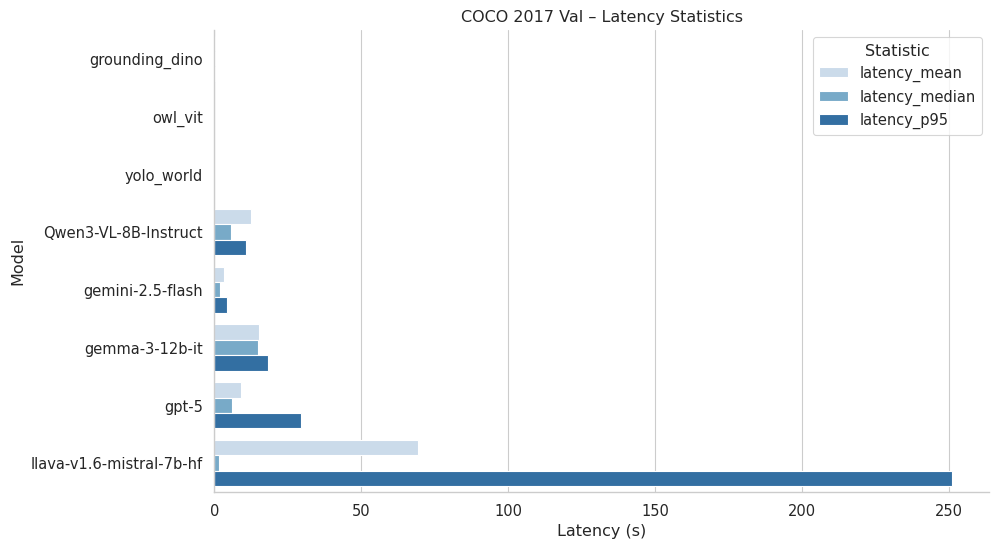

,dataset,model,family,AP,AP50,latency_mean,latency_median,latency_p95,label_accuracy
8,lvis-unseen,grounding_dino,traditional,0.267228,0.311766,0.292924,0.287225,0.319239,0.966887
9,lvis-unseen,owl_vit,traditional,0.141849,0.223416,0.080768,0.080208,0.085718,0.963576
10,lvis-unseen,yolo_world,traditional,0.220512,0.264980,0.047127,0.034645,0.039222,0.981651
11,lvis-unseen,Llama-3.2-11B-Vision-Instruct,vlm,0.000467,0.001239,14.892813,14.943917,17.286762,0.966292
12,lvis-unseen,Qwen3-VL-8B-Instruct,vlm,0.000000,0.000000,23.868815,11.829660,18.206278,0.982143
13,lvis-unseen,gemini-2.5-flash,vlm,0.000010,0.000092,2.592228,2.178360,5.137014,0.989529
14,lvis-unseen,gemma-3-12b-it,vlm,0.000000,0.000000,197.393227,197.356853,198.096554,0.000000
15,lvis-unseen,gpt-5,vlm,0.009102,0.025120,18.851771,17.251215,34.848486,0.989333
16,lvis-unseen,llava-v1.6-mistral-7b-hf,vlm,0.000000,0.000000,138.049166,4.023589,539.934994,0.913907


Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/LVIS_(Unseen)_–_AP_(IoU_0.50:0.95).png
Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/LVIS_(Unseen)_–_AP_(IoU_0.50:0.95).pdf


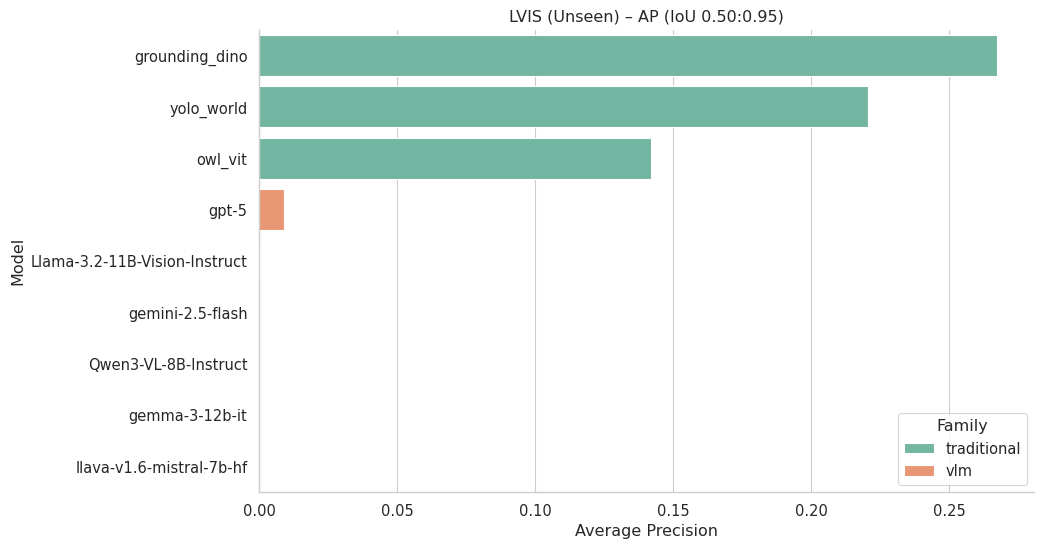

Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/LVIS_(Unseen)_–_AP@0.5.png
Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/LVIS_(Unseen)_–_AP@0.5.pdf


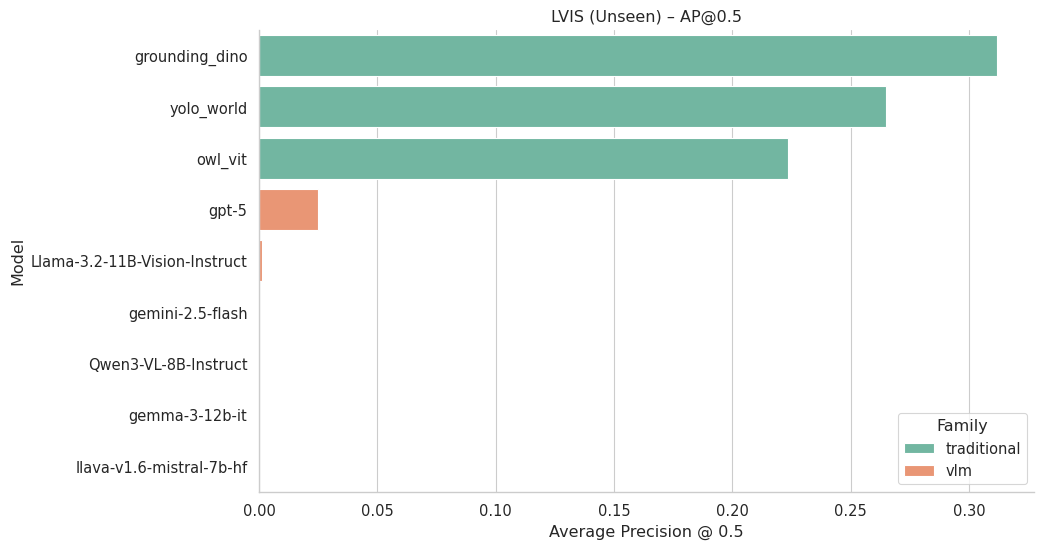

Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/LVIS_(Unseen)_–_Label_Accuracy.png
Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/LVIS_(Unseen)_–_Label_Accuracy.pdf


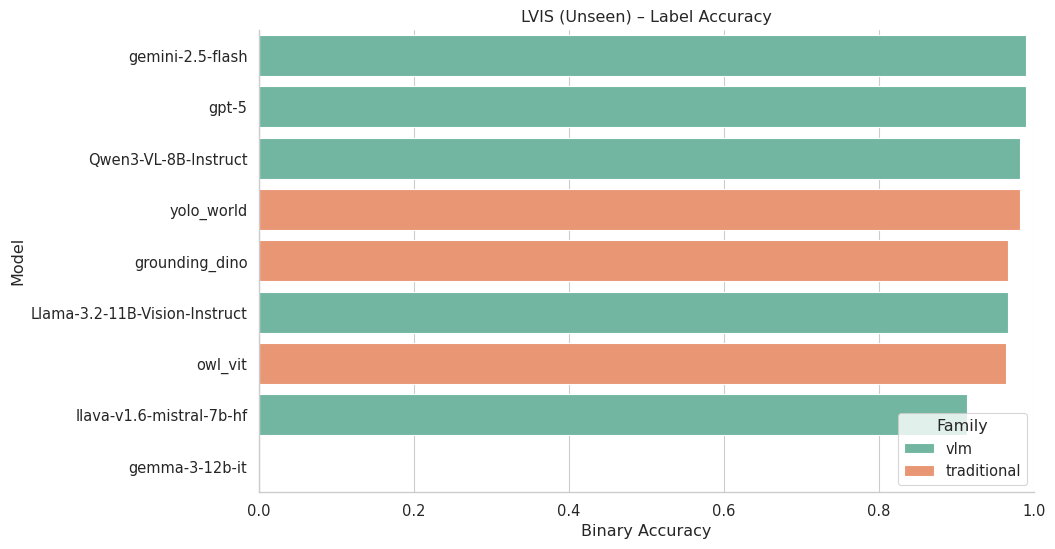

Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/LVIS_(Unseen)_–_Latency_Statistics.png
Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/LVIS_(Unseen)_–_Latency_Statistics.pdf


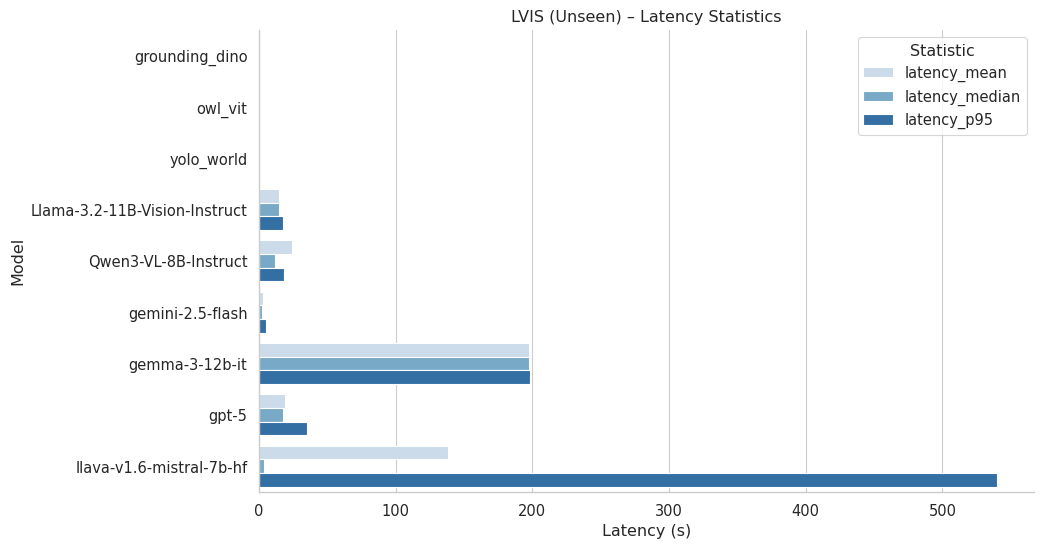

In [4]:
# Full comparison by dataset
for dataset, group in metrics_df.groupby('dataset'):
    label = dataset_label(dataset)
    display(pd.DataFrame(group))

    fig, ax = plot_bar_metric(
        group,
        metric='AP',
        title=f"{label} – AP (IoU 0.50:0.95)",
        ylabel='Average Precision',
    )
    if ax is not None:
        plt.show()

    fig, ax = plot_bar_metric(
        group,
        metric='AP50',
        title=f"{label} – AP@0.5",
        ylabel='Average Precision @ 0.5',
    )
    if ax is not None:
        plt.show()

    fig, ax = plot_bar_metric(
        group,
        metric='label_accuracy',
        title=f"{label} – Label Accuracy",
        ylabel='Binary Accuracy',
    )
    if ax is not None:
        ax.set_xlim(left=0, right=1)
        plt.show()

    fig, ax = plot_latency_box(
        group,
        title=f"{label} – Latency Statistics",
    )
    if ax is not None:
        plt.show()


,dataset,model,family,AP,AP50,latency_mean,latency_median,latency_p95,label_accuracy
3,coco2017-val,Qwen3-VL-8B-Instruct,vlm,0.000013,0.000048,12.478333,5.845668,10.893134,0.206719
4,coco2017-val,gemini-2.5-flash,vlm,0.000037,0.000127,3.362666,2.128692,4.468948,0.313987
5,coco2017-val,gemma-3-12b-it,vlm,0.000000,0.000000,15.415180,14.739154,18.191313,0.000000
6,coco2017-val,gpt-5,vlm,0.002410,0.007619,9.269682,6.076331,29.565728,0.292502
7,coco2017-val,llava-v1.6-mistral-7b-hf,vlm,0.000000,0.000000,69.255604,1.565973,251.231600,0.353635


Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/COCO_2017_Val_–_VLM_AP_(IoU_0.50:0.95).png
Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/COCO_2017_Val_–_VLM_AP_(IoU_0.50:0.95).pdf


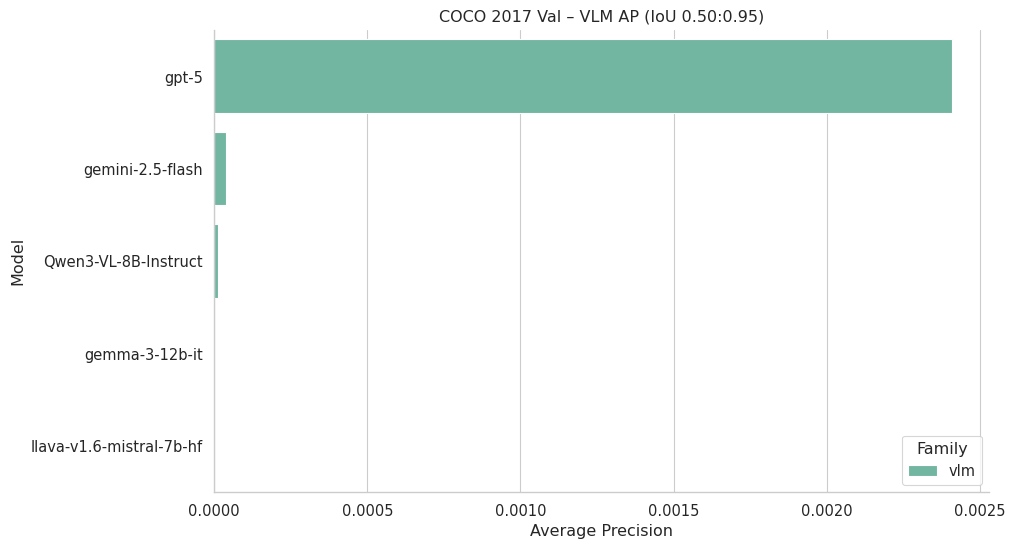

Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/COCO_2017_Val_–_VLM_AP@0.5.png
Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/COCO_2017_Val_–_VLM_AP@0.5.pdf


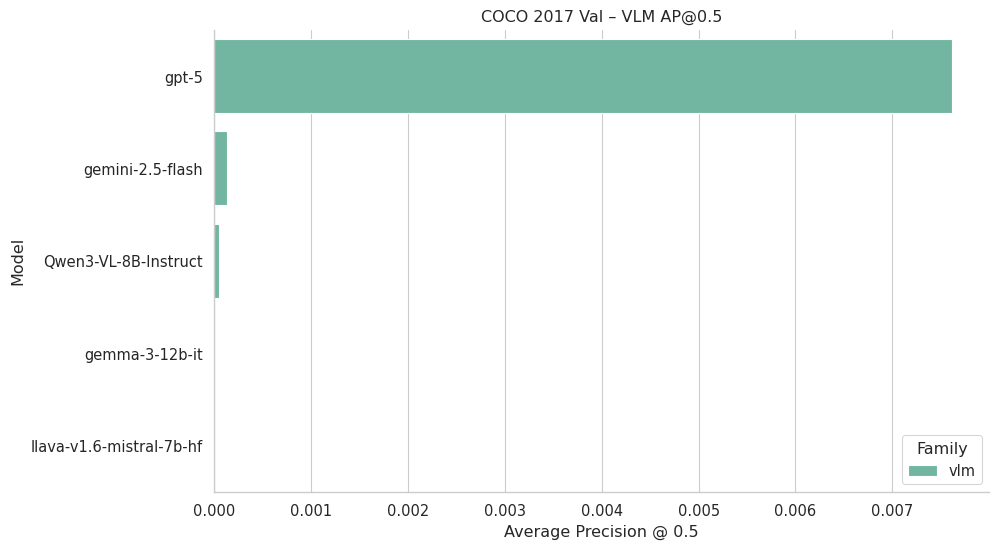

Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/COCO_2017_Val_–_VLM_Label_Accuracy.png
Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/COCO_2017_Val_–_VLM_Label_Accuracy.pdf


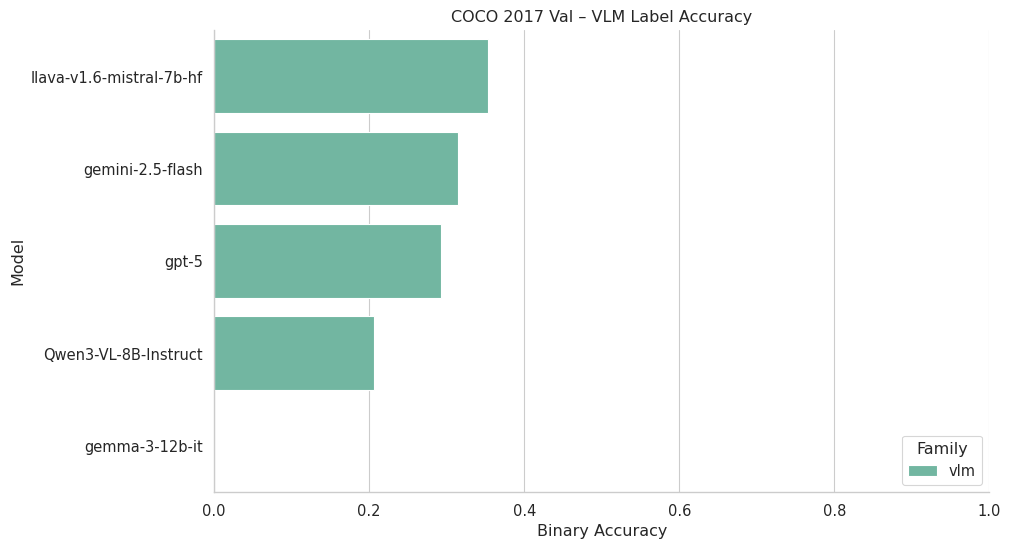

Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/COCO_2017_Val_–_VLM_Latency_Statistics.png
Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/COCO_2017_Val_–_VLM_Latency_Statistics.pdf


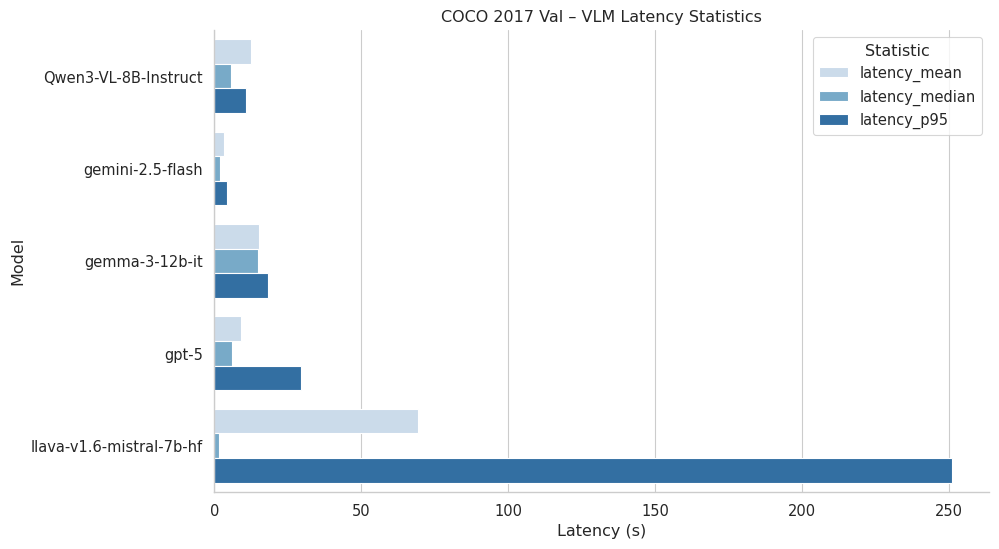

,dataset,model,family,AP,AP50,latency_mean,latency_median,latency_p95,label_accuracy
11,lvis-unseen,Llama-3.2-11B-Vision-Instruct,vlm,0.000467,0.001239,14.892813,14.943917,17.286762,0.966292
12,lvis-unseen,Qwen3-VL-8B-Instruct,vlm,0.000000,0.000000,23.868815,11.829660,18.206278,0.982143
13,lvis-unseen,gemini-2.5-flash,vlm,0.000010,0.000092,2.592228,2.178360,5.137014,0.989529
14,lvis-unseen,gemma-3-12b-it,vlm,0.000000,0.000000,197.393227,197.356853,198.096554,0.000000
15,lvis-unseen,gpt-5,vlm,0.009102,0.025120,18.851771,17.251215,34.848486,0.989333
16,lvis-unseen,llava-v1.6-mistral-7b-hf,vlm,0.000000,0.000000,138.049166,4.023589,539.934994,0.913907


Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/LVIS_(Unseen)_–_VLM_AP_(IoU_0.50:0.95).png
Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/LVIS_(Unseen)_–_VLM_AP_(IoU_0.50:0.95).pdf


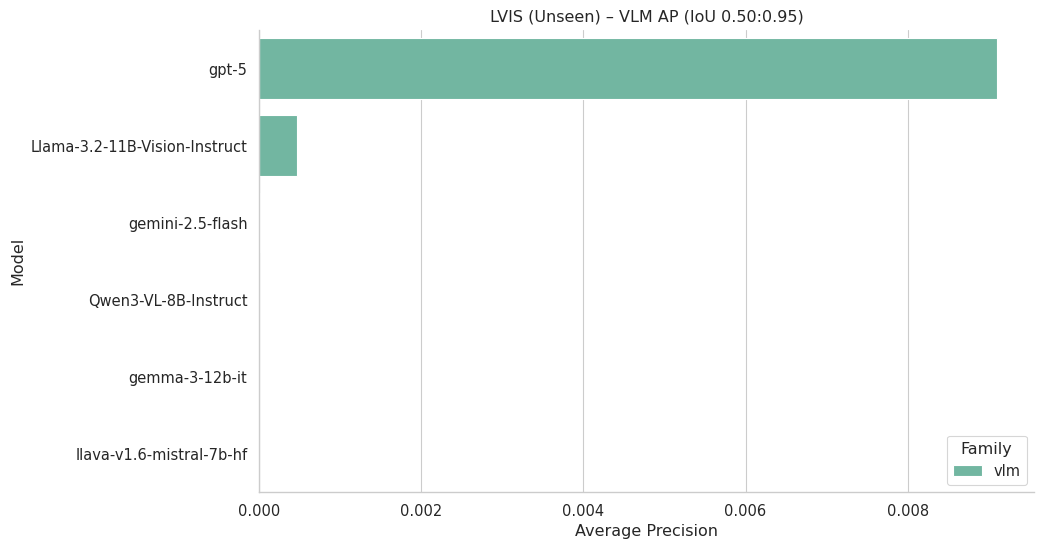

Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/LVIS_(Unseen)_–_VLM_AP@0.5.png
Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/LVIS_(Unseen)_–_VLM_AP@0.5.pdf


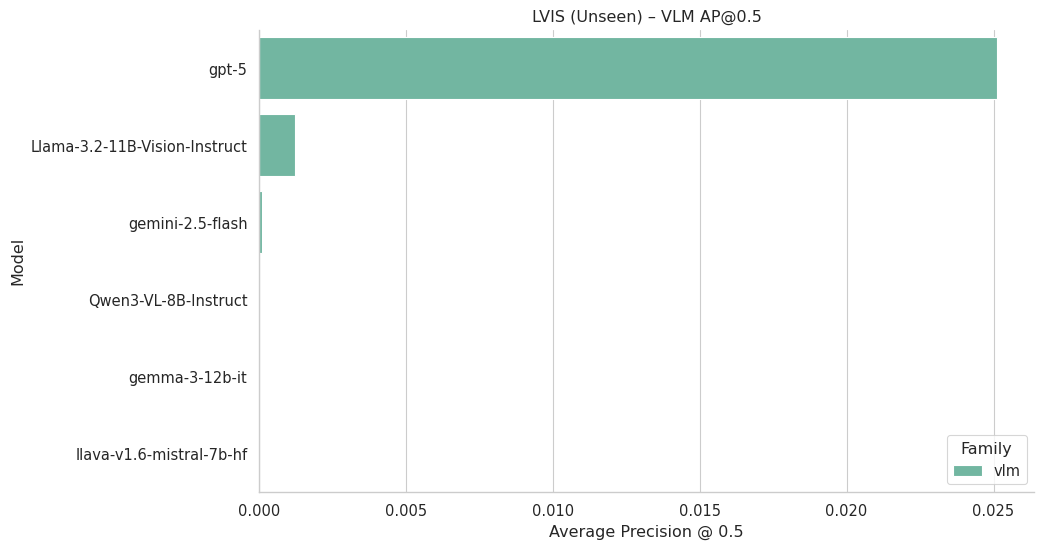

Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/LVIS_(Unseen)_–_VLM_Label_Accuracy.png
Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/LVIS_(Unseen)_–_VLM_Label_Accuracy.pdf


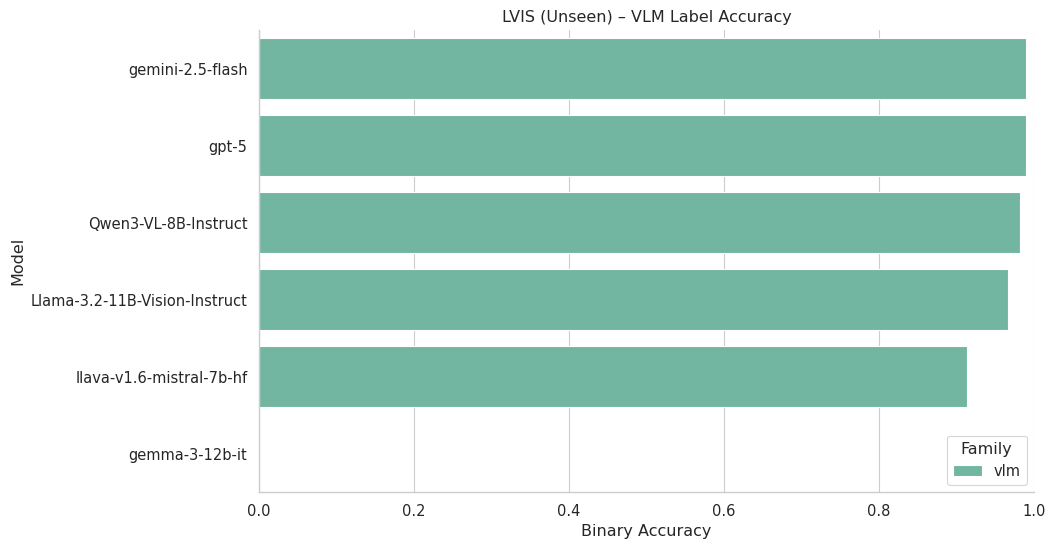

Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/LVIS_(Unseen)_–_VLM_Latency_Statistics.png
Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/LVIS_(Unseen)_–_VLM_Latency_Statistics.pdf


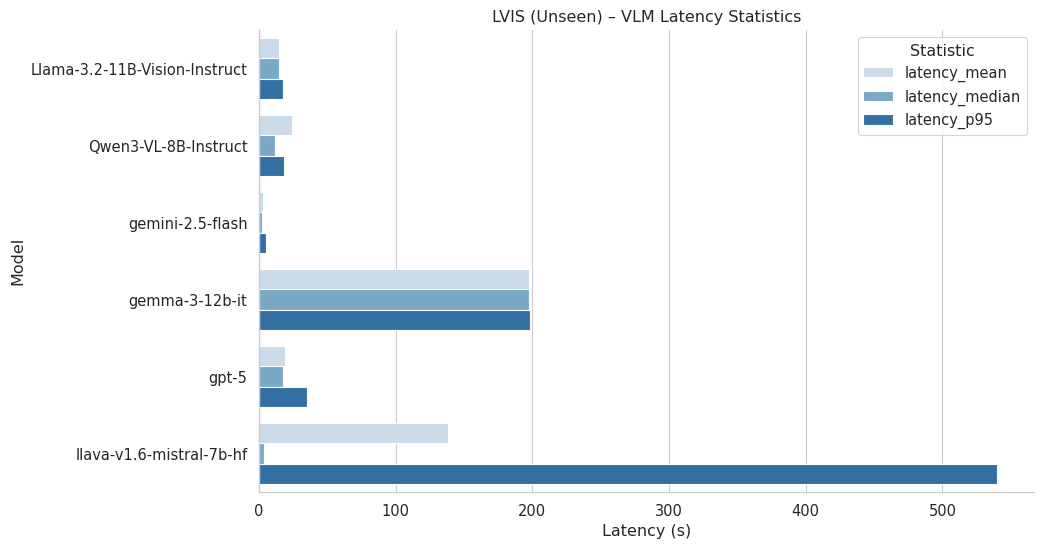

In [5]:
# VLM-only comparison
vlm_df = metrics_df[metrics_df['family'] == 'vlm']
for dataset, group in vlm_df.groupby('dataset'):
    label = dataset_label(dataset)
    if group.empty:
        continue
    display(pd.DataFrame(group))

    fig, ax = plot_bar_metric(
        group,
        metric='AP',
        title=f"{label} – VLM AP (IoU 0.50:0.95)",
        ylabel='Average Precision',
    )
    if ax is not None:
        plt.show()

    fig, ax = plot_bar_metric(
        group,
        metric='AP50',
        title=f"{label} – VLM AP@0.5",
        ylabel='Average Precision @ 0.5',
    )
    if ax is not None:
        plt.show()

    fig, ax = plot_bar_metric(
        group,
        metric='label_accuracy',
        title=f"{label} – VLM Label Accuracy",
        ylabel='Binary Accuracy',
    )
    if ax is not None:
        ax.set_xlim(left=0, right=1)
        plt.show()

    fig, ax = plot_latency_box(
        group,
        title=f"{label} – VLM Latency Statistics",
    )
    if ax is not None:
        plt.show()


## Long-tail Focus (LVIS Unseen)
If your summary JSON contains per-category AP or you want to highlight performance on rare classes, extend the loader to pull those values. The snippet below assumes you augment `metrics_summary.json` with an optional `tail_ap` field.

In [6]:
if "tail_ap" in metrics_df.columns:
    lvis_df = metrics_df[metrics_df["dataset"] == "lvis-unseen"].dropna(subset=["tail_ap"])
    if not lvis_df.empty:
        plot_bar_metric(
            lvis_df,
            metric="tail_ap",
            title="LVIS Unseen – Long-tail AP",
            ylabel="Average Precision (rare classes)",
        )
        plt.show()
    else:
        print("No long-tail AP data found in the summary.")

## Exporting Figures
Use the following helper to save plots in both PNG and PDF formats ready for your manuscript.

In [7]:
def save_figure(fig, name: str, output_dir: Path = PROJECT_ROOT / "results" / "figures"):
    output_dir.mkdir(parents=True, exist_ok=True)
    for ext in ("png", "pdf"):
        fig_path = output_dir / f"{name}.{ext}"
        fig.savefig(fig_path, bbox_inches="tight")
        print(f"Saved: {fig_path}")

After running the plotting cells above, call `save_figure` on any figure you want to embed in the paper.

Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/Scatter_LVIS_AP_vs_Accuracy.png
Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/Scatter_LVIS_AP_vs_Accuracy.pdf


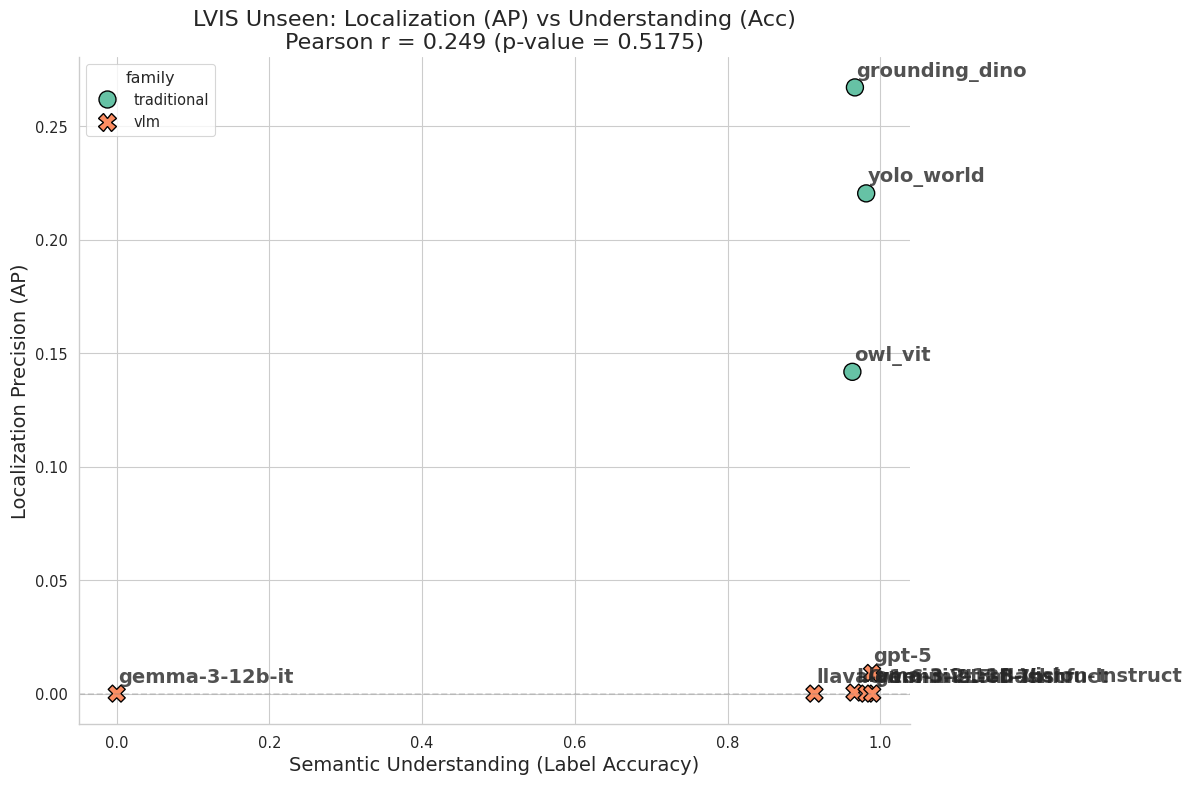

In [11]:
from scipy.stats import pearsonr

# 1. Filtrar datos solo para LVIS Unseen (donde la 'amnesia espacial' es crítica)
# Asegúrate de que el nombre del dataset coincida con lo que tienes en tu JSON (ej. 'lvis-unseen')
scatter_data = metrics_df[metrics_df['dataset'] == 'lvis-unseen'].copy()

# Limpiar datos nulos si los hubiera
scatter_data = scatter_data.dropna(subset=['label_accuracy', 'AP'])

if not scatter_data.empty:
    # 2. Calcular Correlación de Pearson
    r, p_value = pearsonr(scatter_data['label_accuracy'], scatter_data['AP'])

    # 3. Crear el gráfico
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Definir paleta de colores consistente con tus otros gráficos
    # Usamos 'hue' y 'style' para diferenciar familias claramente
    sns.scatterplot(
        data=scatter_data, 
        x='label_accuracy', 
        y='AP', 
        hue='family', 
        style='family', 
        s=150,               # Tamaño de los puntos
        palette='Set2',      # O la paleta que prefieras
        edgecolor='black',   # Borde negro para que resalten
        ax=ax
    )

    # 4. Anotar cada punto con el nombre del modelo
    # Usamos iterrows para recorrer los datos filtrados
    for i, row in scatter_data.iterrows():
        # Pequeño desplazamiento para que el texto no tape el punto
        ax.text(
            row['label_accuracy'] + 0.002, 
            row['AP'] + 0.005, 
            row['model'], 
            fontsize=14, 
            weight='bold',
            alpha=0.8
        )

    # 5. Decoración del gráfico
    ax.set_title(f"LVIS Unseen: Localization (AP) vs Understanding (Acc)\nPearson r = {r:.3f} (p-value = {p_value:.4f})", fontsize=16)
    ax.set_xlabel("Semantic Understanding (Label Accuracy)", fontsize=14)
    ax.set_ylabel("Localization Precision (AP)", fontsize=14)

    # Opcional: Ajustar límites si los VLMs se amontonan a la derecha
    # ax.set_xlim(0.5, 1.05) 
    # ax.set_ylim(-0.02, 0.35)

    # Línea discontinua en AP=0 para enfatizar el colapso de los VLMs
    ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
    
    sns.despine(ax=ax)
    plt.tight_layout()

    # 6. Guardar usando tu función auxiliar
    save_figure(fig, "Scatter_LVIS_AP_vs_Accuracy")
    plt.show()

else:
    print("No data found for dataset 'lvis-unseen'. Check your dataset keys in metrics_df.")

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

def plot_bar_metric(df: pd.DataFrame, metric: str, title: str, ylabel: str, figsize=(6, 4)):
    """Render a horizontal bar chart 'paper-ready'."""
    if metric not in df.columns:
        return None, None

    subset = df.dropna(subset=[metric]).copy()
    if subset.empty:
        return None, None

    # ---- Estilo general para paper ----
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

    sns.set_context("paper", font_scale=1.3)
    sns.set_style("whitegrid", {
        "grid.linestyle": "--",
        "grid.alpha": 0.4,
    })

    # Ordenar por métrica (desc)
    order = subset.sort_values(metric, ascending=False)

    # Paleta sobria por familia
    palette = {
        "traditional": "#4C72B0",  # azul
        "vlm": "#DD8452",          # naranja
    }

    fig, ax = plt.subplots(figsize=figsize)

    sns.barplot(
        data=order,
        y="model",
        x=metric,
        hue="family",
        dodge=False,
        palette=palette,
        edgecolor="black",
        linewidth=0.6,
        ax=ax,
    )

    # AP en porcentaje (si está en [0,1])
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=1))
    ax.set_xlabel("AP (%)  (IoU 0.50:0.95)")
    ax.set_ylabel("Model")

    ax.set_title(title, pad=10)

    # Leyenda limpia
    leg = ax.legend(title="Family", loc="lower right", frameon=False)

    # Rejilla sólo vertical
    ax.grid(axis="x")
    ax.grid(axis="y", visible=False)

    sns.despine(ax=ax, left=False, bottom=False)

    fig.tight_layout()

    save_figure(fig, name=title.replace(" ", "_").lower())
    return fig, ax


,dataset,model,family,AP,AP50,latency_mean,latency_median,latency_p95,label_accuracy
0,coco2017-val,grounding_dino,traditional,0.073079,0.095342,0.110914,0.111802,0.121823,0.269769
1,coco2017-val,owl_vit,traditional,0.027787,0.043251,0.024105,0.024063,0.025706,0.221271
2,coco2017-val,yolo_world,traditional,0.057252,0.075801,0.016150,0.015471,0.017178,0.221193
3,coco2017-val,Qwen3-VL-8B-Instruct,vlm,0.000013,0.000048,12.478333,5.845668,10.893134,0.206719
4,coco2017-val,gemini-2.5-flash,vlm,0.000037,0.000127,3.362666,2.128692,4.468948,0.313987
5,coco2017-val,gemma-3-12b-it,vlm,0.000000,0.000000,15.415180,14.739154,18.191313,0.000000
6,coco2017-val,gpt-5,vlm,0.002410,0.007619,9.269682,6.076331,29.565728,0.292502
7,coco2017-val,llava-v1.6-mistral-7b-hf,vlm,0.000000,0.000000,69.255604,1.565973,251.231600,0.353635


Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/coco_2017_val_–_ap_(iou_0.50:0.95).png
Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/coco_2017_val_–_ap_(iou_0.50:0.95).pdf


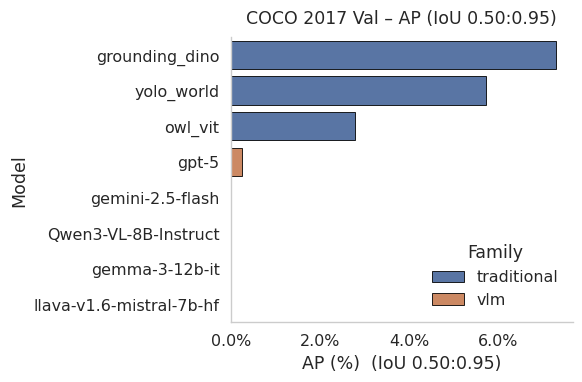

Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/coco_2017_val_–_ap@0.5.png
Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/coco_2017_val_–_ap@0.5.pdf


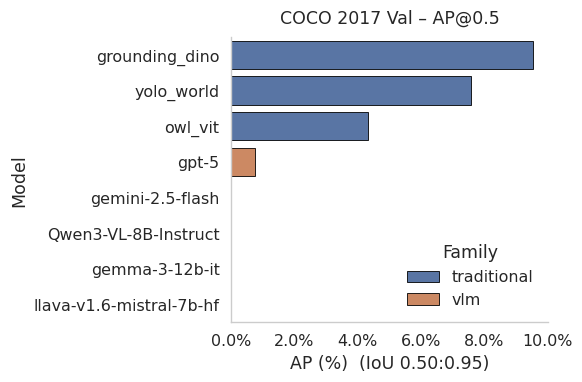

Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/coco_2017_val_–_label_accuracy.png
Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/coco_2017_val_–_label_accuracy.pdf


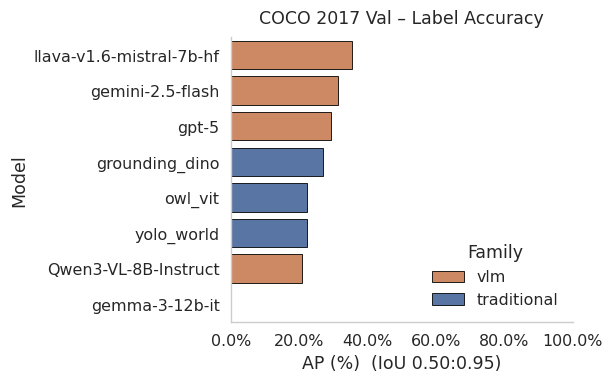

Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/COCO_2017_Val_–_Latency_Statistics.png
Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/COCO_2017_Val_–_Latency_Statistics.pdf


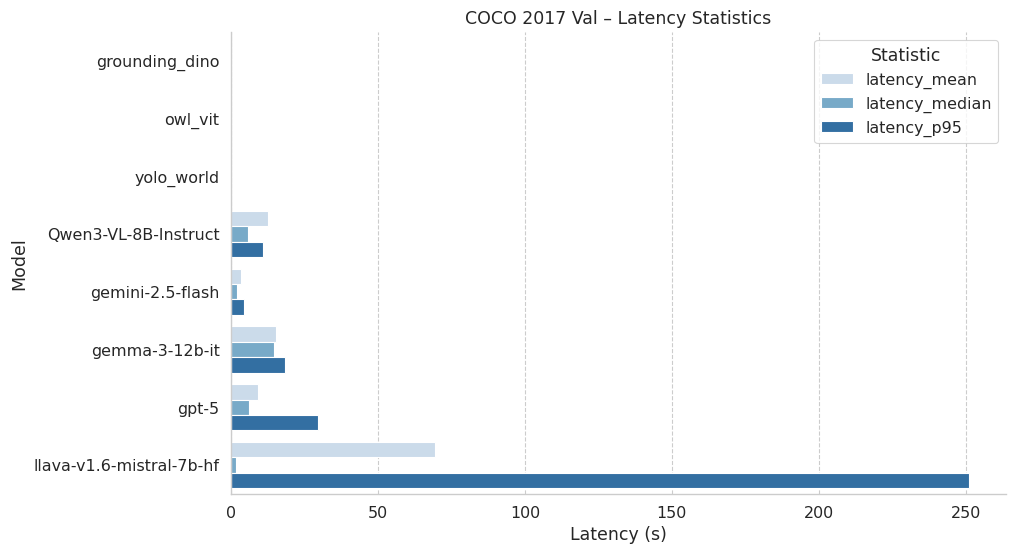

,dataset,model,family,AP,AP50,latency_mean,latency_median,latency_p95,label_accuracy
8,lvis-unseen,grounding_dino,traditional,0.267228,0.311766,0.292924,0.287225,0.319239,0.966887
9,lvis-unseen,owl_vit,traditional,0.141849,0.223416,0.080768,0.080208,0.085718,0.963576
10,lvis-unseen,yolo_world,traditional,0.220512,0.264980,0.047127,0.034645,0.039222,0.981651
11,lvis-unseen,Llama-3.2-11B-Vision-Instruct,vlm,0.000467,0.001239,14.892813,14.943917,17.286762,0.966292
12,lvis-unseen,Qwen3-VL-8B-Instruct,vlm,0.000000,0.000000,23.868815,11.829660,18.206278,0.982143
13,lvis-unseen,gemini-2.5-flash,vlm,0.000010,0.000092,2.592228,2.178360,5.137014,0.989529
14,lvis-unseen,gemma-3-12b-it,vlm,0.000000,0.000000,197.393227,197.356853,198.096554,0.000000
15,lvis-unseen,gpt-5,vlm,0.009102,0.025120,18.851771,17.251215,34.848486,0.989333
16,lvis-unseen,llava-v1.6-mistral-7b-hf,vlm,0.000000,0.000000,138.049166,4.023589,539.934994,0.913907


Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/lvis_(unseen)_–_ap_(iou_0.50:0.95).png
Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/lvis_(unseen)_–_ap_(iou_0.50:0.95).pdf


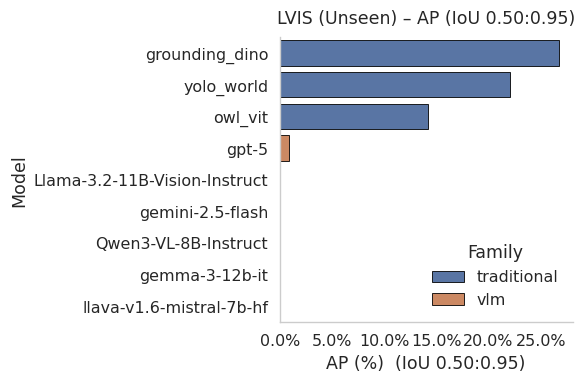

Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/lvis_(unseen)_–_ap@0.5.png
Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/lvis_(unseen)_–_ap@0.5.pdf


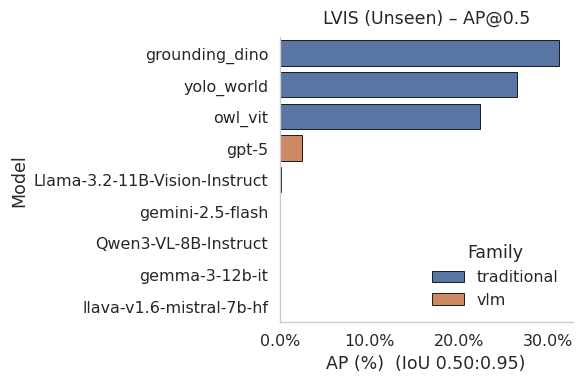

Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/lvis_(unseen)_–_label_accuracy.png
Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/lvis_(unseen)_–_label_accuracy.pdf


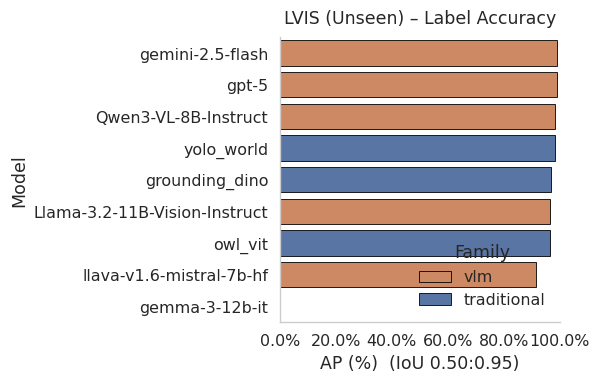

Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/LVIS_(Unseen)_–_Latency_Statistics.png
Saved: /home/maxim/PycharmProjects/zero-shot-detection-benchmark/experiments/results/figures/LVIS_(Unseen)_–_Latency_Statistics.pdf


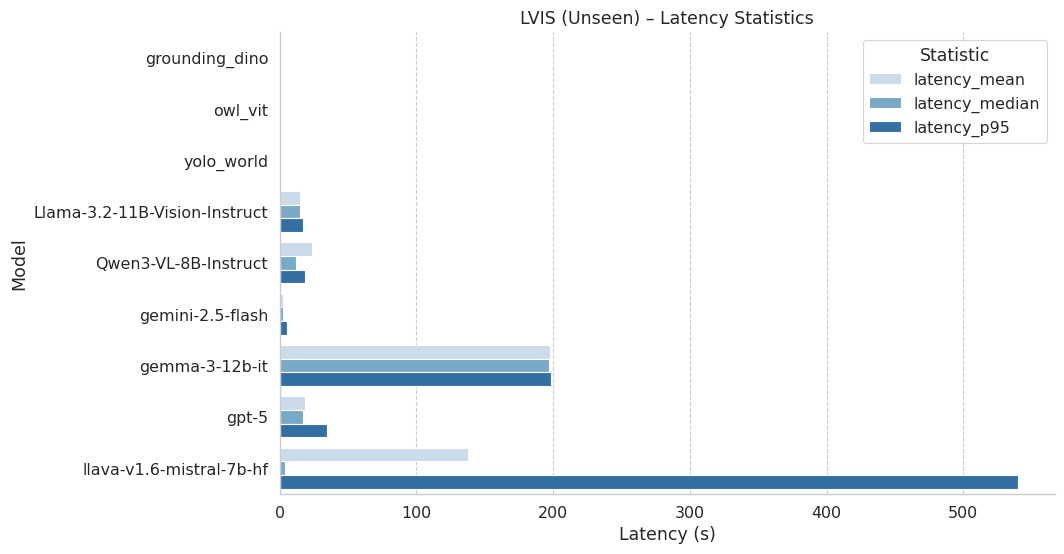

In [17]:
# Full comparison by dataset
for dataset, group in metrics_df.groupby('dataset'):
    label = dataset_label(dataset)
    display(pd.DataFrame(group))

    fig, ax = plot_bar_metric(
        group,
        metric='AP',
        title=f"{label} – AP (IoU 0.50:0.95)",
        ylabel='Average Precision',
    )
    if ax is not None:
        plt.show()

    fig, ax = plot_bar_metric(
        group,
        metric='AP50',
        title=f"{label} – AP@0.5",
        ylabel='Average Precision @ 0.5',
    )
    if ax is not None:
        plt.show()

    fig, ax = plot_bar_metric(
        group,
        metric='label_accuracy',
        title=f"{label} – Label Accuracy",
        ylabel='Binary Accuracy',
    )
    if ax is not None:
        ax.set_xlim(left=0, right=1)
        plt.show()

    fig, ax = plot_latency_box(
        group,
        title=f"{label} – Latency Statistics",
    )
    if ax is not None:
        plt.show()
